<a href="https://colab.research.google.com/github/Ibrah-N/Deep-Learning-Projects-Computer-Vision/blob/main/Pytorch_3_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
import tensorflow.keras as keras
import torch

from matplotlib import pyplot as plt
from PIL import Image
import numpy

!pip install torchinfo

# Data Preparation

In [2]:
# download data
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train = x_train[:20000]
y_train = y_train[:20000]

x_test = x_test[:1000]
y_test = y_test[:1000]


print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")


print(f"Shape of X_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of x_train: (20000, 28, 28)
Shape of y_train: (20000,)
Shape of X_test: (1000, 28, 28)
Shape of y_test: (1000,)


In [4]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

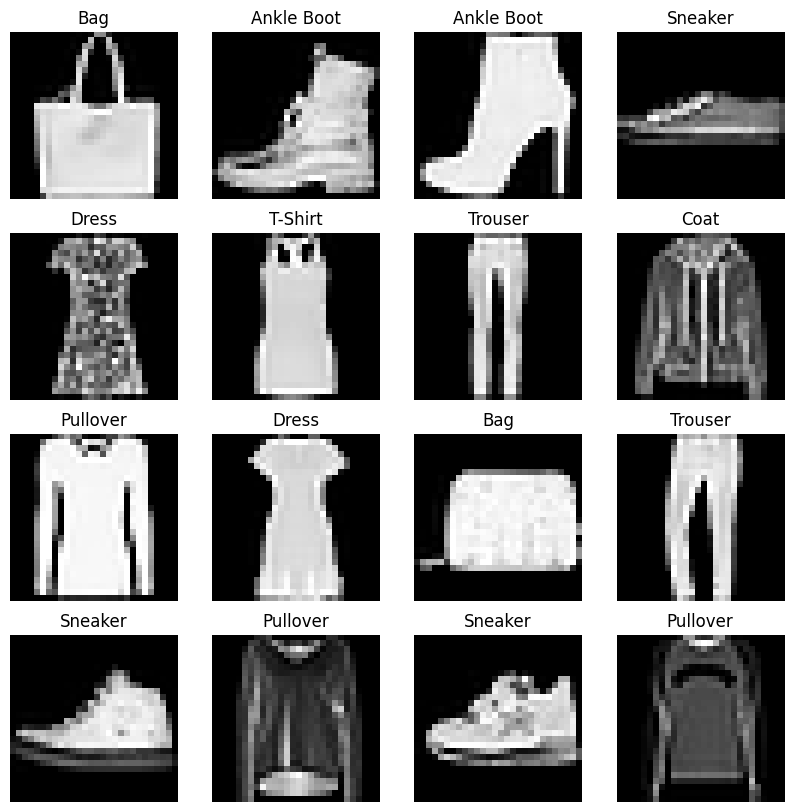

In [5]:
fig = plt.figure(figsize=(10, 10))
nrows, ncols = 4, 4

for i in range(1, nrows * ncols + 1):
  sample_idx = torch.randint(len(x_train), size=(1,)).item()
  image = x_train[sample_idx]
  label = y_train[sample_idx]


  fig.add_subplot(nrows, ncols, i)
  plt.axis("off")
  plt.title(labels_map[label])
  plt.imshow(image, cmap="gray")


In [6]:
x = x_train[0]
print(x.dtype)

uint8


In [7]:
from torchvision.transforms import ToTensor, Normalize, Compose, Resize, CenterCrop, Lambda
import PIL

transforms = Compose([
    Resize(256),
    CenterCrop(224),
    Lambda(lambda img: img.convert("RGB")),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


class MNistDataset(torch.utils.data.Dataset):

  def __init__(self, images, labels, transforms=None):
    self.images = images
    self.labels = labels
    self.transforms = transforms


  def __len__(self):
    return len(self.images)


  def __getitem__(self, idx):

    image = PIL.Image.fromarray(self.images[idx])
    label = self.labels[idx]

    if self.transforms:
      image = self.transforms(image)
      return image, label

    else:
      return image, label


In [8]:
from torch.utils.data import DataLoader


train_dataset = MNistDataset(x_train, y_train, transforms)
valid_dataset = MNistDataset(x_test, y_test, transforms)


train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, drop_last=True)

In [10]:
print("*"*10, "Training Dataset", "*"*10)
for images, labels in train_loader:
  print(images.shape)
  print(labels.shape)
  break


print("\n","*"*10, "Validation Dataset", "*"*10)
for image, labels in valid_loader:
  print(images.shape)
  print(labels.shape)
  break

********** Training Dataset **********
torch.Size([32, 3, 224, 224])
torch.Size([32])

 ********** Validation Dataset **********
torch.Size([32, 3, 224, 224])
torch.Size([32])


# Building Model

In [37]:
import torchvision
import torchinfo # Added import for torchinfo

# pretrained model
base_model = torchvision.models.mobilenet_v2(pretrained=True)

# model summary
torchinfo.summary(base_model) # Changed to use torchinfo.summary

Layer (type:depth-idx)                             Param #
MobileNetV2                                        --
├─Sequential: 1-1                                  --
│    └─Conv2dNormActivation: 2-1                   --
│    │    └─Conv2d: 3-1                            864
│    │    └─BatchNorm2d: 3-2                       64
│    │    └─ReLU6: 3-3                             --
│    └─InvertedResidual: 2-2                       --
│    │    └─Sequential: 3-4                        896
│    └─InvertedResidual: 2-3                       --
│    │    └─Sequential: 3-5                        5,136
│    └─InvertedResidual: 2-4                       --
│    │    └─Sequential: 3-6                        8,832
│    └─InvertedResidual: 2-5                       --
│    │    └─Sequential: 3-7                        10,000
│    └─InvertedResidual: 2-6                       --
│    │    └─Sequential: 3-8                        14,848
│    └─InvertedResidual: 2-7                       --
│    │ 

In [38]:
class MNistModel(torch.nn.Module):

  def __init__(self, base_model, NUM_CLASSES = 10):
    super().__init__()

    self.feature_extractor = base_model.features
    self.classifier = torch.nn.Sequential(
        torch.nn.AdaptiveAvgPool2d((1, 1)),
        torch.nn.Flatten(),
        torch.nn.Linear(in_features=1280, out_features=128),
        torch.nn.ReLU(),

        torch.nn.Dropout(0.2),
        torch.nn.Linear(in_features=128, out_features=64),
        torch.nn.ReLU(),

        torch.nn.Linear(in_features=64, out_features=NUM_CLASSES)
    )


  def forward(self, x):
    x = self.feature_extractor(x)
    x = self.classifier(x)

    return x

In [39]:
mnist_model = MNistModel(base_model, NUM_CLASSES=10)

In [40]:
for param in mnist_model.feature_extractor.parameters():
  param.requires_grad = False

In [41]:
torchinfo.summary(mnist_model, input_size=(1, 3, 224, 224))

Layer (type:depth-idx)                             Output Shape              Param #
MNistModel                                         [1, 10]                   --
├─Sequential: 1-1                                  [1, 1280, 7, 7]           --
│    └─Conv2dNormActivation: 2-1                   [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                            [1, 32, 112, 112]         (864)
│    │    └─BatchNorm2d: 3-2                       [1, 32, 112, 112]         (64)
│    │    └─ReLU6: 3-3                             [1, 32, 112, 112]         --
│    └─InvertedResidual: 2-2                       [1, 16, 112, 112]         --
│    │    └─Sequential: 3-4                        [1, 16, 112, 112]         (896)
│    └─InvertedResidual: 2-3                       [1, 24, 56, 56]           --
│    │    └─Sequential: 3-5                        [1, 24, 56, 56]           (5,136)
│    └─InvertedResidual: 2-4                       [1, 24, 56, 56]           --
│    │    └─Sequential

In [42]:
learning_rate = 0.0001
EPOCHS = 10
optim = torch.optim.Adam(mnist_model.parameters(), lr=learning_rate)
loss = torch.nn.CrossEntropyLoss()

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [44]:
TRAIN_SIZE = len(train_loader)
VALID_SIZE = len(valid_loader)

In [ ]:
from IPython.display import clear_output

epoch_logs = []

mnist_model = mnist_model.to(device)

for epoch in range(EPOCHS):

    train_loss = 0
    valid_loss = 0
    train_acc = 0
    valid_acc = 0

    # ===== Training =====
    mnist_model.train()

    for batch_Idx, (batch_image, batch_labels) in enumerate(train_loader):

        batch_image = batch_image.to(device)
        batch_labels = batch_labels.to(device)

        y_pred = mnist_model(batch_image)

        t_loss = loss(y_pred, batch_labels)
        t_acc = (y_pred.argmax(dim=-1) == batch_labels).float().mean()

        optim.zero_grad()
        t_loss.backward()
        optim.step()

        train_loss += t_loss.item()
        train_acc += t_acc.item()

        clear_output(wait=True)

        # print previous epoch results again
        for log in epoch_logs:
            print(log)

        # live batch update
        print(f"Epoch {epoch+1}/{EPOCHS} | Batch {batch_Idx+1}/{TRAIN_SIZE} "
              f"| Loss {t_loss:.4f} | Acc {t_acc:.4f}")

    # ===== Validation =====
    mnist_model.eval()

    for batch_image, batch_labels in valid_loader:

        batch_image = batch_image.to(device)
        batch_labels = batch_labels.to(device)

        with torch.no_grad():
            y_pred = mnist_model(batch_image)

            v_loss = loss(y_pred, batch_labels)
            v_acc = (y_pred.argmax(dim=-1) == batch_labels).float().mean()

            valid_loss += v_loss.item()
            valid_acc += v_acc.item()

    # epoch summary
    log = (
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"loss {train_loss/TRAIN_SIZE:.4f} | "
        f"acc {train_acc/TRAIN_SIZE:.4f} | "
        f"val_loss {valid_loss/VALID_SIZE:.4f} | "
        f"val_acc {valid_acc/VALID_SIZE:.4f}"
    )

    epoch_logs.append(log)

    clear_output(wait=True)

    for log in epoch_logs:
        print(log)

Epoch 1/10 | loss 1.3109 | acc 0.5969 | val_loss 0.7333 | val_acc 0.7792
Epoch 2/10 | loss 0.7273 | acc 0.7511 | val_loss 0.5665 | val_acc 0.8075
Epoch 3/10 | loss 0.6233 | acc 0.7822 | val_loss 0.5139 | val_acc 0.8226
Epoch 4/10 | loss 0.5748 | acc 0.7995 | val_loss 0.4605 | val_acc 0.8438
Epoch 5/10 | loss 0.5388 | acc 0.8122 | val_loss 0.4429 | val_acc 0.8569
Epoch 6/10 | loss 0.5147 | acc 0.8173 | val_loss 0.4364 | val_acc 0.8508
Epoch 7/10 | Batch 581/625 | Loss 0.4006 | Acc 0.9062


# Model Evaluation